<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Mohd_Abuzar/Infosys_Internship_Visual_Exploration_%26_Delay_Trends.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Milestone 2: Visual Exploration and Delay Trends**

**Week 3:** Univariate and Bivariate Visual Analysis
* Top airlines, routes, and busiest months
* Flight distribution by day, time, and airport
* Plot bar charts, histograms, boxplots, and line plots

**Week 4:** Delay Analysis – Airline and Weather
* Compare delay causes by airline
* Explore carrier delays, weather delays, NAS delays
* Visualize delays by time of day and airport

**Deliverables:**
* Set of visualizations (minimum 8)
* Observations on peak delays and top delay-prone carriers

#**Week 3:** Univariate and Bivariate Visual Analysis
* Top airlines, routes, and busiest months
* Flight distribution by day, time, and airport
* Plot bar charts, histograms, boxplots, and line plots

## Step 1: Importing required libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better aesthetics
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

## Step 2: Loading Dataset.

In [2]:
print("Importing Flights dataset...")
try:
  df = pd.read_parquet('/content/drive/MyDrive/Infosys_Springboard_Dataset/Preprocessed dataset/preprocessed_flights.parquet')
  print("Successfully imported Flights dataset!")
except Exception as e:
  print(f"Error importing dataset: {e}")

Importing Flights dataset...
Successfully imported Flights dataset!


In [3]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 51 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   YEAR                      int16         
 1   MONTH                     int8          
 2   DAY                       int8          
 3   DAY_OF_WEEK               int8          
 4   AIRLINE                   category      
 5   FLIGHT_NUMBER             int16         
 6   TAIL_NUMBER               category      
 7   ORIGIN_AIRPORT            object        
 8   DESTINATION_AIRPORT       object        
 9   SCHEDULED_DEPARTURE       int16         
 10  DEPARTURE_TIME            float32       
 11  DEPARTURE_DELAY           float32       
 12  TAXI_OUT                  float32       
 13  WHEELS_OFF                float32       
 14  SCHEDULED_TIME            float32       
 15  ELAPSED_TIME              float32       
 16  AIR_TIME                  float32       
 17  DISTANCE

## Step 3: Visualization for finding outliers

### 3.1: Visualization using BOXPOLT.

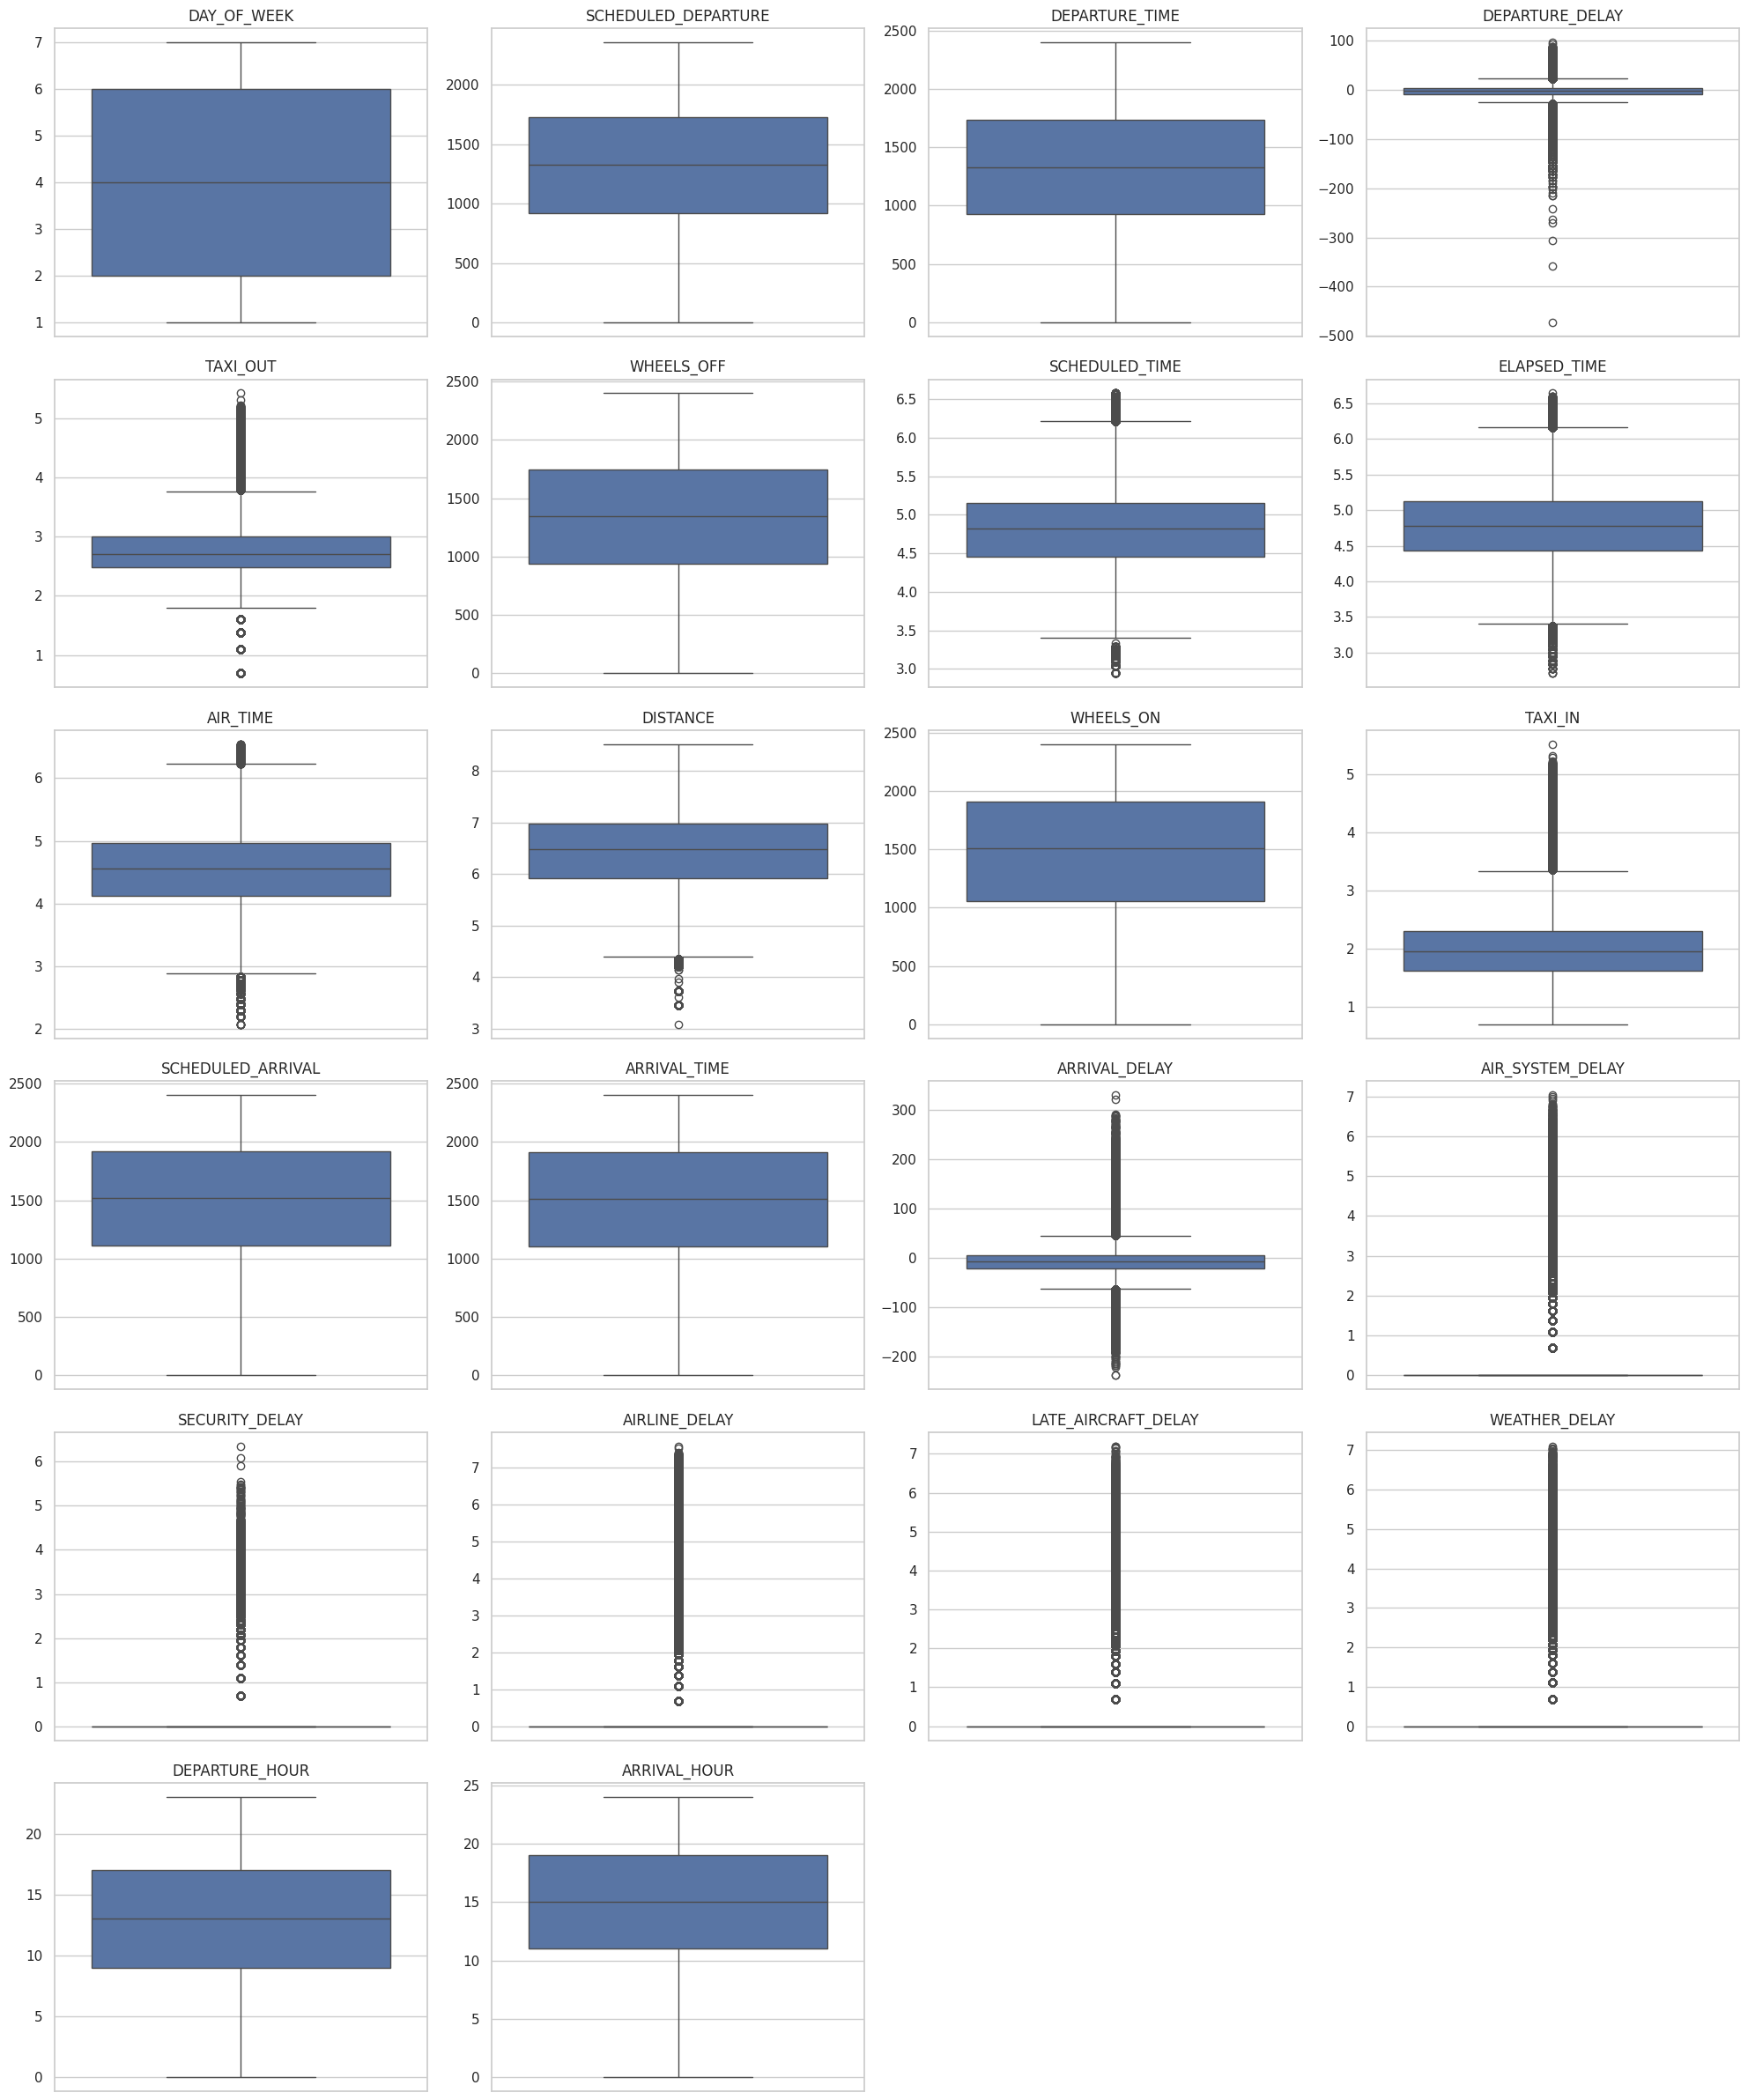

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Columns to be excluded from the plot
columns_to_exclude = [
    'YEAR', 'MONTH', 'DAY', 'FLIGHT_NUMBER', 'DIVERTED', 'CANCELLED',
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DESTINATION_LATITUDE',
    'DESTINATION_LONGITUDE'
]

# Filter numerical_cols to exclude the specified columns
cols_for_this_plot = [col for col in numerical_cols if col not in columns_to_exclude]

# Calculate the number of rows and columns for subplots based on the actual number of columns to plot
n_cols = 4 # Number of columns for the subplot grid
n_rows = (len(cols_for_this_plot) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plot_idx = 1 # Initialize a separate counter for subplot positions

for col in cols_for_this_plot:
    plt.subplot(n_rows, n_cols, plot_idx)
    sns.boxplot(y=df[col])
    plt.title(f'{col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plot_idx += 1 # Increment only when a plot is made

plt.tight_layout()
plt.show()

 **Interpretation: Box Plots of Numerical Features**

These box plots show the distribution and potential outliers for various numerical columns:
*   **Outliers:** Many columns exhibit numerous outliers, especially on the upper end, indicating extreme values (e.g., very long delays or taxi times).
*   **Skewness:** The position of the median within the box and the length of the whiskers suggest varying degrees of skewness across features.
*   **Variability:** The spread of each box (interquartile range) and whiskers highlights the variability within each feature.

Overall, the plots are crucial for identifying data ranges, central tendencies, and the presence of extreme values.

### 3.2: Visualization using HISTOGRAM.

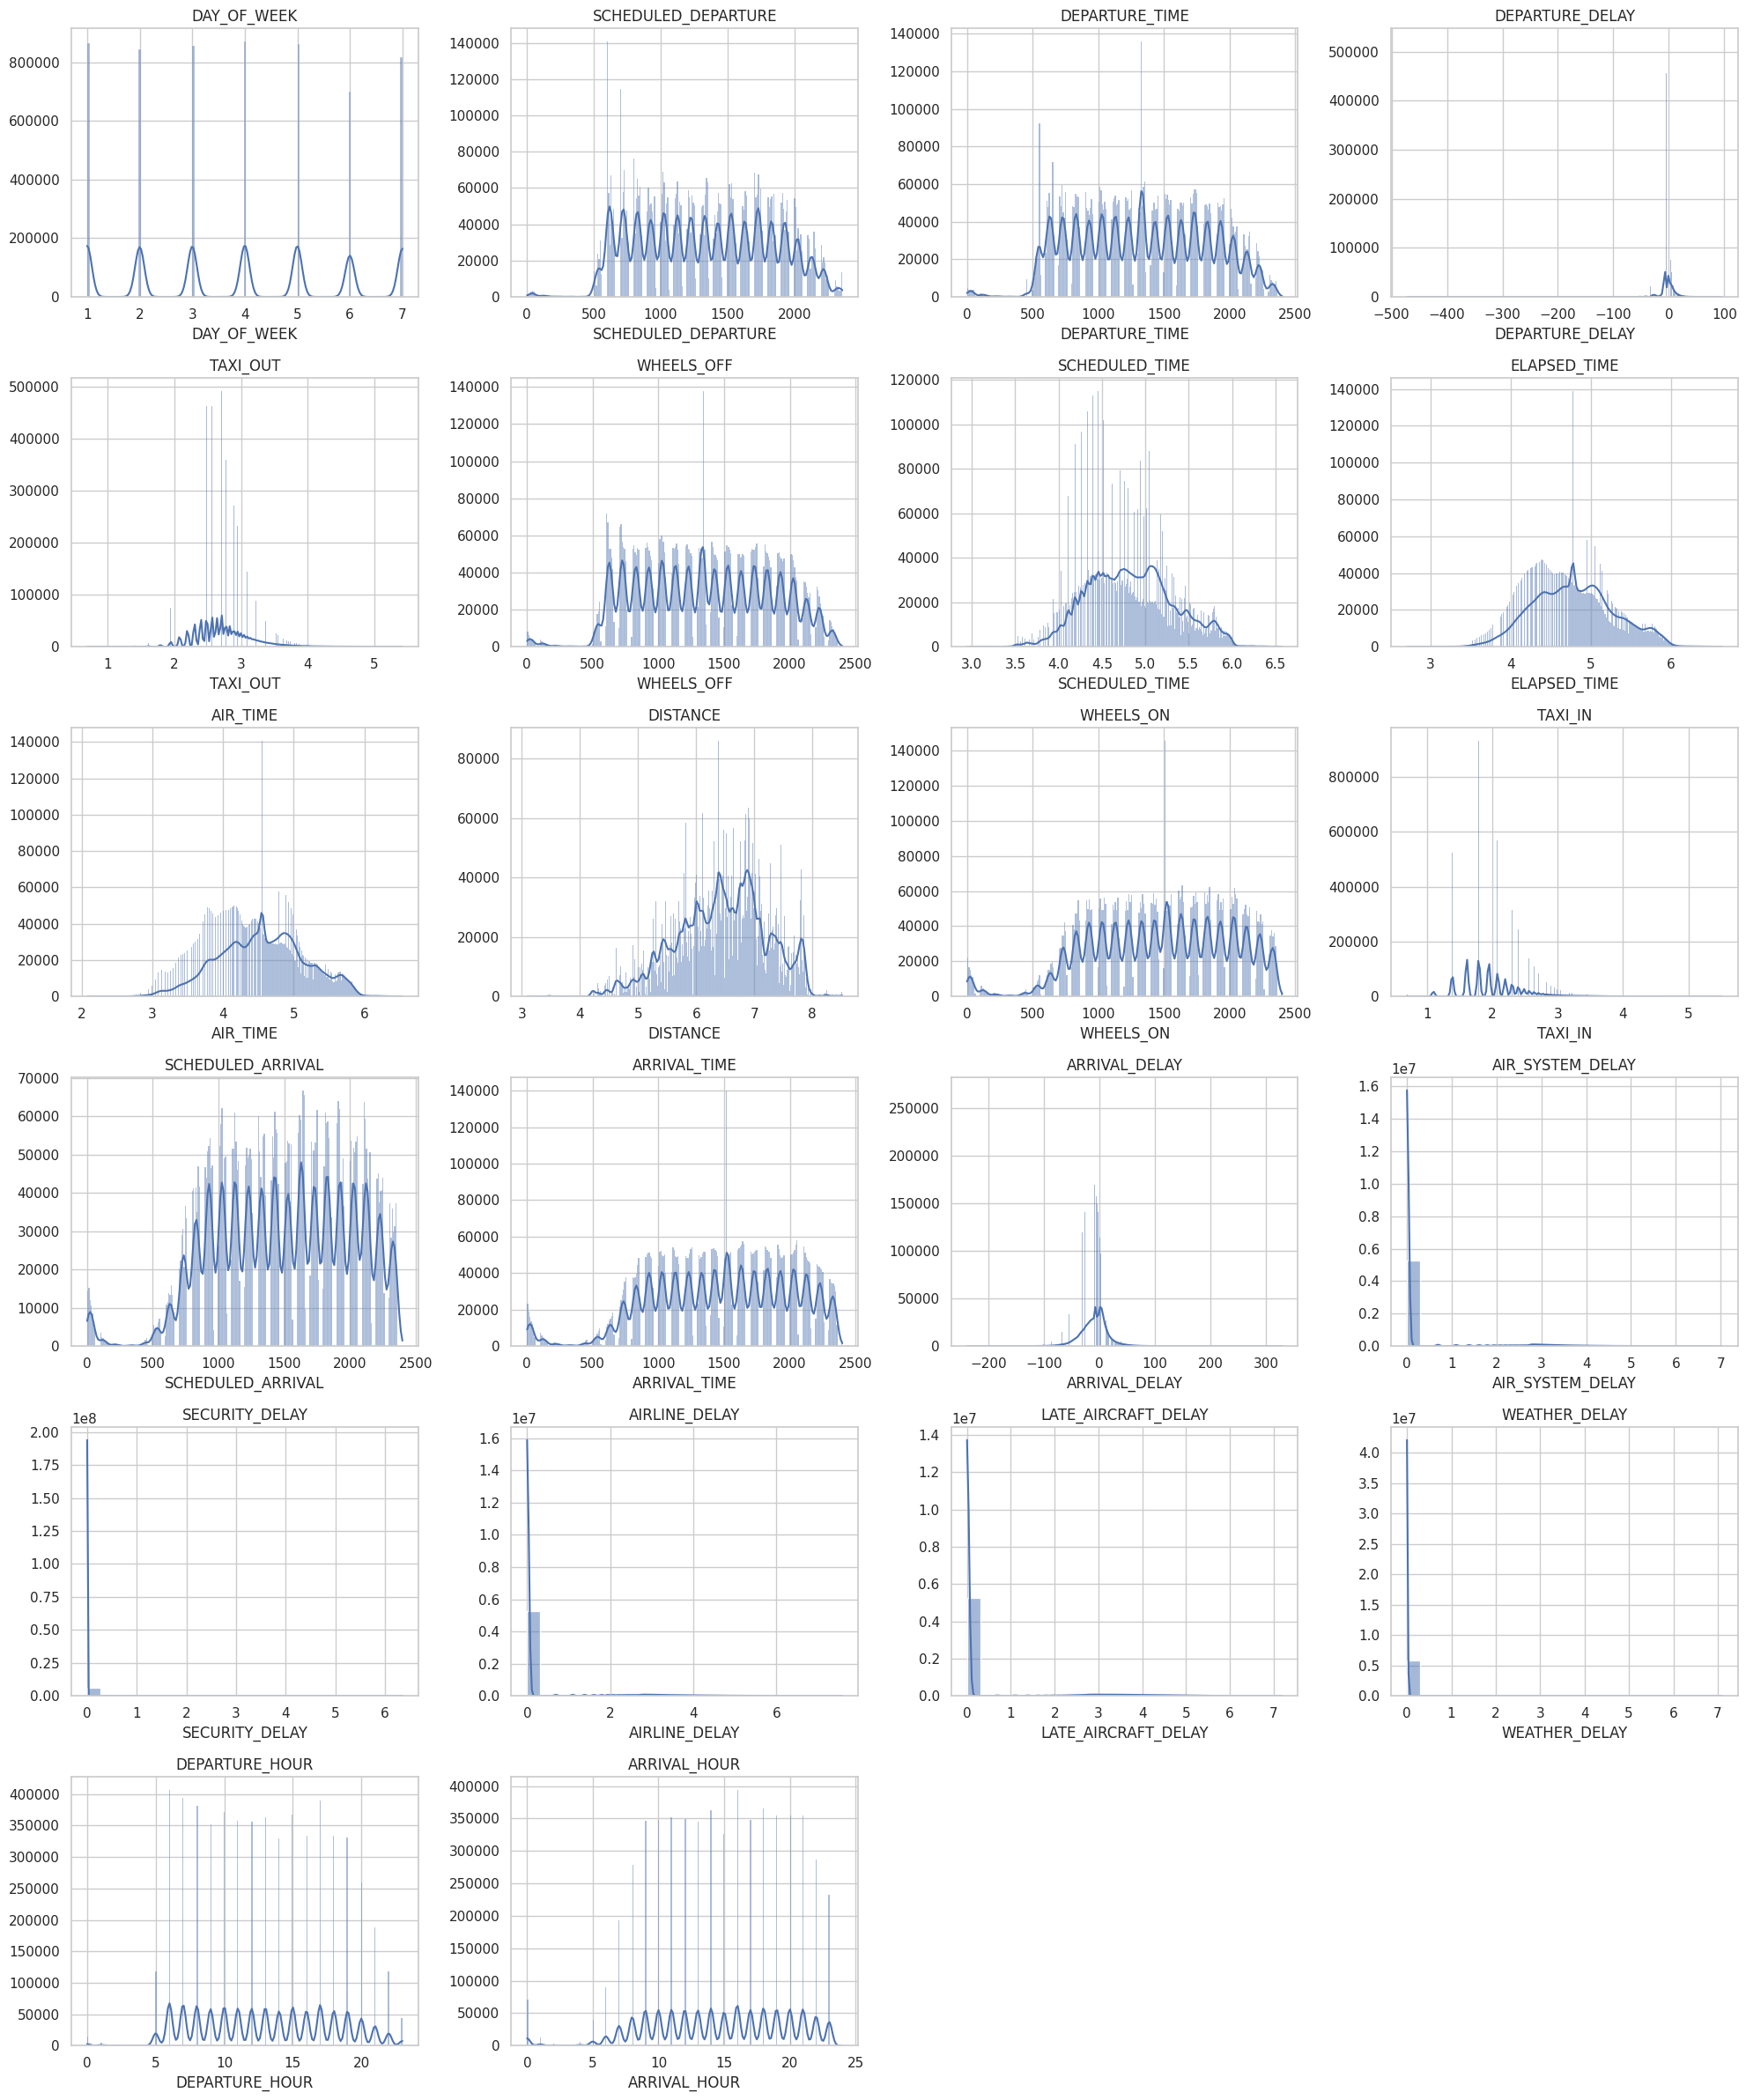

In [70]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Columns to be excluded from the plot
columns_to_exclude = [
    'YEAR', 'MONTH', 'DAY', 'FLIGHT_NUMBER', 'DIVERTED', 'CANCELLED',
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE', 'DESTINATION_LATITUDE',
    'DESTINATION_LONGITUDE'
]

# Filter numerical_cols to exclude the specified columns
cols_for_this_plot = [col for col in numerical_cols if col not in columns_to_exclude]

# Calculate the number of rows and columns for subplots
n_cols = 4 # Number of columns for the subplot grid
n_rows = (len(cols_for_this_plot) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4))
plot_idx = 1
for col in cols_for_this_plot:
    plt.subplot(n_rows, n_cols, plot_idx)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col}')
    plt.ylabel('') # Remove y-label to avoid clutter
    plot_idx += 1
plt.tight_layout()
plt.show()

**Interpretation: Histograms of Numerical Features**

These histograms display the distribution of various numerical columns:
*   **Skewness:** Many delay-related features initially show strong right skewness, indicating frequent short delays and fewer long ones.
*   **Transformed Data:** After transformations (Yeo-Johnson or Log1p), the distributions are generally more symmetric, closer to a normal distribution.
*   **Other Features:** Time-based and distance features often show multimodal or varied distributions, reflecting operational patterns.

Overall, the plots reveal underlying data distributions, improved after skewness reduction.

## Step 4: Applying Transformation(Yeo-Johnson Power Transformation and Log1p Transformation).

In [6]:
from sklearn.preprocessing import PowerTransformer
import warnings

# Suppress harmless warnings from PowerTransformer
warnings.filterwarnings('ignore', message='Input data is sparse or has too many unique values for PowerTransformer. Consider using StandardScaler instead.')
warnings.filterwarnings('ignore', message='PowerTransformer does not support non-positive values with the Box-Cox method.')

# List of numerical columns identified as potential candidates for transformation based on common data characteristics.
# Columns like YEAR, MONTH, DAY, FLIGHT_NUMBER, binary flags (DIVERTED, CANCELLED),
# and geographical coordinates (LATITUDE, LONGITUDE) are generally not suitable for skewness transformations.
columns_to_transform = [
    'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME',
    'DISTANCE', 'TAXI_IN', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
    'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'
]

transformed_cols_info = {}

print("Applying outlier handling transformations where appropriate...")
for col in columns_to_transform:
    if col not in df.columns:
        print(f"Column '{col}' not found in DataFrame. Skipping.")
        continue

    # Check for constant column which PowerTransformer might struggle with
    if df[col].nunique() <= 1:
        print(f"Column '{col}' is constant or has too few unique values, skipping transformation.")
        continue

    skew_val = df[col].skew()
    print(f"\nProcessing column: {col}, Initial Skewness: {skew_val:.4f}")

    # Thresholds for significant skewness (absolute value)
    skew_threshold = 0.5

    # Check if there are any negative values in the column
    has_negative_values = (df[col] < 0).any()

    if skew_val > skew_threshold: # Right-skewed
        if has_negative_values:
            print(f"  Applying Yeo-Johnson Power Transformation for right-skewed '{col}' (has negative values).")
            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            # Reshape for PowerTransformer, which expects 2D array
            df[col] = pt.fit_transform(df[[col]])
            transformed_cols_info[col] = 'Yeo-Johnson (right-skewed, negative values present)'
        else:
            print(f"  Applying Log1p Transformation for right-skewed '{col}'.")
            df[col] = np.log1p(df[col])
            transformed_cols_info[col] = 'Log1p (right-skewed)'
        print(f"  New Skewness: {df[col].skew():.4f}")
    elif skew_val < -skew_threshold: # Left-skewed
        print(f"  Applying Yeo-Johnson Power Transformation for left-skewed '{col}'.")
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        # Reshape for PowerTransformer, which expects 2D array
        df[col] = pt.fit_transform(df[[col]])
        transformed_cols_info[col] = 'Yeo-Johnson (left-skewed)'
        print(f"  New Skewness: {df[col].skew():.4f}")
    else:
        print(f"  Skewness of '{col}' ({skew_val:.4f}) is within acceptable range (|skew| < {skew_threshold}), no transformation applied.")

print("\n--- Summary of Transformations Applied ---")
if transformed_cols_info:
    for col, method in transformed_cols_info.items():
        print(f"- '{col}': {method}")
else:
    print("No significant skewness detected in eligible columns, no transformations applied.")

print("\nDataFrame head after transformations:")
display(df.head())

Applying outlier handling transformations where appropriate...

Processing column: DEPARTURE_DELAY, Initial Skewness: 7.6470
  Applying Yeo-Johnson Power Transformation for right-skewed 'DEPARTURE_DELAY' (has negative values).


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


  New Skewness: -0.4187

Processing column: TAXI_OUT, Initial Skewness: 3.5002
  Applying Log1p Transformation for right-skewed 'TAXI_OUT'.
  New Skewness: 0.6717

Processing column: SCHEDULED_TIME, Initial Skewness: 1.3449
  Applying Log1p Transformation for right-skewed 'SCHEDULED_TIME'.
  New Skewness: 0.1678

Processing column: ELAPSED_TIME, Initial Skewness: 1.3769
  Applying Log1p Transformation for right-skewed 'ELAPSED_TIME'.
  New Skewness: 0.1476

Processing column: AIR_TIME, Initial Skewness: 1.4026
  Applying Log1p Transformation for right-skewed 'AIR_TIME'.
  New Skewness: -0.0284

Processing column: DISTANCE, Initial Skewness: 1.4225
  Applying Log1p Transformation for right-skewed 'DISTANCE'.
  New Skewness: -0.2636

Processing column: TAXI_IN, Initial Skewness: 5.1750
  Applying Log1p Transformation for right-skewed 'TAXI_IN'.
  New Skewness: 0.8771

Processing column: ARRIVAL_DELAY, Initial Skewness: 6.5651
  Applying Yeo-Johnson Power Transformation for right-skewed '

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


  New Skewness: -0.0478

Processing column: AIR_SYSTEM_DELAY, Initial Skewness: 13.1013
  Applying Log1p Transformation for right-skewed 'AIR_SYSTEM_DELAY'.
  New Skewness: 3.3008

Processing column: SECURITY_DELAY, Initial Skewness: 168.6650
  Applying Log1p Transformation for right-skewed 'SECURITY_DELAY'.
  New Skewness: 46.2646

Processing column: AIRLINE_DELAY, Initial Skewness: 18.6232
  Applying Log1p Transformation for right-skewed 'AIRLINE_DELAY'.
  New Skewness: 3.3769

Processing column: LATE_AIRCRAFT_DELAY, Initial Skewness: 9.1880
  Applying Log1p Transformation for right-skewed 'LATE_AIRCRAFT_DELAY'.
  New Skewness: 3.1706

Processing column: WEATHER_DELAY, Initial Skewness: 38.0176
  Applying Log1p Transformation for right-skewed 'WEATHER_DELAY'.
  New Skewness: 10.6992

--- Summary of Transformations Applied ---
- 'DEPARTURE_DELAY': Yeo-Johnson (right-skewed, negative values present)
- 'TAXI_OUT': Log1p (right-skewed)
- 'SCHEDULED_TIME': Log1p (right-skewed)
- 'ELAPSED_

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,DEPARTURE_HOUR,ARRIVAL_HOUR,FLIGHT_DATE,ROUTE,DAY_OF_WEEK_NAME,IS_WEEKEND,DEPARTURE_TIME_BLOCK
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-26.194378,3.091043,15.0,5.327876,5.273000,5.135798,7.278629,404.0,1.609438,430,408.0,-42.265583,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,0,4,2015-01-01,ANC-SEA,Thursday,False,Night
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-16.863209,2.564949,14.0,5.638355,5.634789,5.575949,7.754053,737.0,1.609438,750,741.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Palm Beach International Airport,West Palm Beach,FL,USA,26.683161,-80.095589,0,7,2015-01-01,LAX-PBI,Thursday,False,Night
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.764579,2.833213,34.0,5.659482,5.683580,5.587249,7.739359,800.0,2.484907,806,811.0,3.664161,0,0,NA,0.0,0.0,0.0,0.0,0.0,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.618999,-122.374840,Charlotte Douglas International Airport,Charlotte,NC,USA,35.214008,-80.943130,0,8,2015-01-01,SFO-CLT,Thursday,False,Night
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-8.938113,2.772589,30.0,5.655992,5.641907,5.556828,7.759187,748.0,2.197225,805,756.0,-14.063154,0,0,NA,0.0,0.0,0.0,0.0,0.0,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.942539,-118.408073,Miami International Airport,Miami,FL,USA,25.793249,-80.290558,0,8,2015-01-01,LAX-MIA,Thursday,False,Night
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.210559,2.484907,35.0,5.463832,5.375278,5.298317,7.278629,254.0,1.791759,320,259.0,-39.887878,0,0,NA,0.0,0.0,0.0,0.0,0.0,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.448978,-122.309311,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.174320,-149.996185,0,3,2015-01-01,SEA-ANC,Thursday,False,Night


**Interpretation of Data Transformations**

This cell applies **Yeo-Johnson Power Transformation** and **Log1p Transformation** to several numerical columns in the DataFrame `df`. The primary goal of these transformations is to reduce the skewness of the data distribution, making it more Gaussian-like (bell-shaped). This is often a crucial step in preparing data for many machine learning models, which perform better with normally distributed inputs, and for statistical analyses that assume normality.

Here's a breakdown of what's happening:

*   **`columns_to_transform`**: A specific list of numerical columns was identified as potential candidates for transformation. These are typically continuous variables that often exhibit skewness, such as various delay types, time durations, and distance.

*   **Skewness Check**: For each column, the initial skewness is calculated. A `skew_threshold` (set to 0.5) is used to determine if a column is significantly skewed (either positively or negatively).

*   **Transformation Logic**: The code intelligently selects the transformation method:
    *   **Log1p Transformation (`np.log1p(df[col])`)**: This is applied to right-skewed columns that *do not* contain negative values. `log1p(x)` computes `log(1+x)`, which handles zero values gracefully and is effective at compressing large positive values.
    *   **Yeo-Johnson Power Transformation (`PowerTransformer(method='yeo-johnson')`)**: This method is more versatile as it can be applied to data that contains zero or negative values. It's used for both right-skewed columns that *do* contain negative values (like `DEPARTURE_DELAY` and `ARRIVAL_DELAY`) and left-skewed columns.

*   **Impact**: After transformation, the skewness of most of the processed columns is significantly reduced, bringing them closer to a symmetric distribution. For example:
    *   `DEPARTURE_DELAY` skewness changed from 7.6470 to -0.4187.
    *   `ARRIVAL_DELAY` skewness changed from 6.5651 to -0.0478.
    *   `SCHEDULED_TIME` skewness changed from 1.3449 to 0.1678.

**Note on Warning**: The output shows warnings about `PowerTransformer` not supporting non-positive values with the Box-Cox method. This is because the code correctly switches to `yeo-johnson` when negative values are present, so these warnings are harmless in this context, indicating that the `yeo-johnson` method was indeed used as intended for those columns.

By transforming these columns, the dataset is better prepared for subsequent modeling steps, which can lead to more robust and accurate analytical results.

## Step 5:  Univariate and Bivariate Visual Analysis.

### 5.1: Top Airlines by Number of Flights.

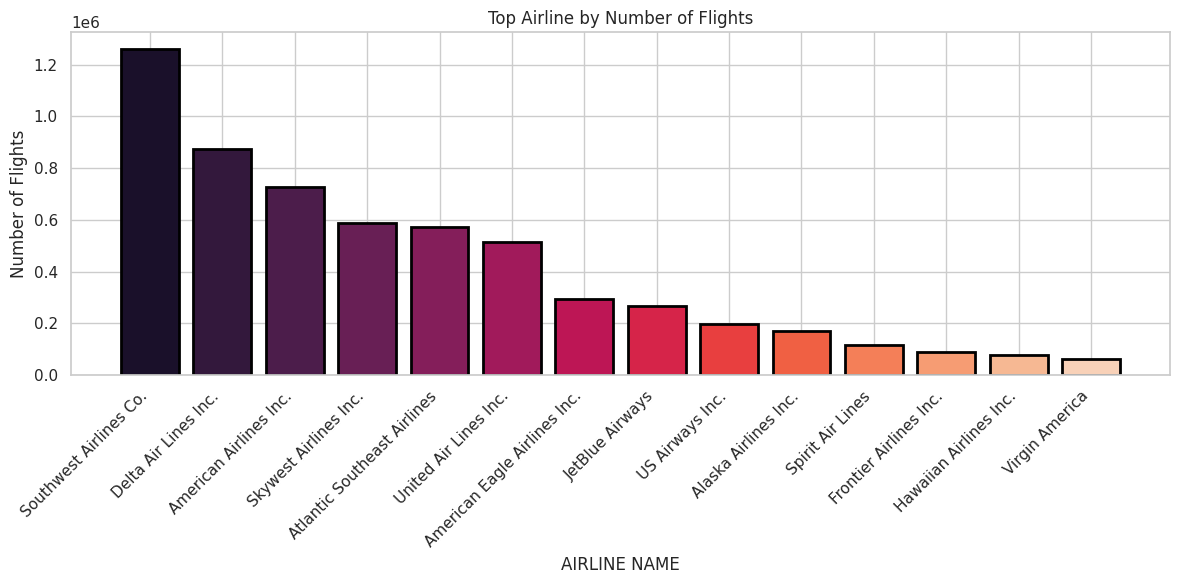

In [7]:
plt.figure(figsize=(12, 6))
# Calculate the number of flights per airline
airline_counts = df['AIRLINE_NAME'].value_counts()
color = sns.color_palette("rocket", len(airline_counts))

plt.bar(airline_counts.index, airline_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Top Airline by Number of Flights')
plt.xlabel('AIRLINE NAME')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top Airlines**

This chart shows the number of flights per airline:
*   **Leaders:** Southwest, Delta, and American Airlines lead in flight volume.
*   **Mid-Tier:** Skywest, Atlantic Southeast, and United also have significant operations.
*   **Smaller:** Frontier and Allegiant operate fewer flights.

Overall, flight activity is concentrated among a few major carriers.

### 5.2: Top 20 Most Frequent Flight Routes.

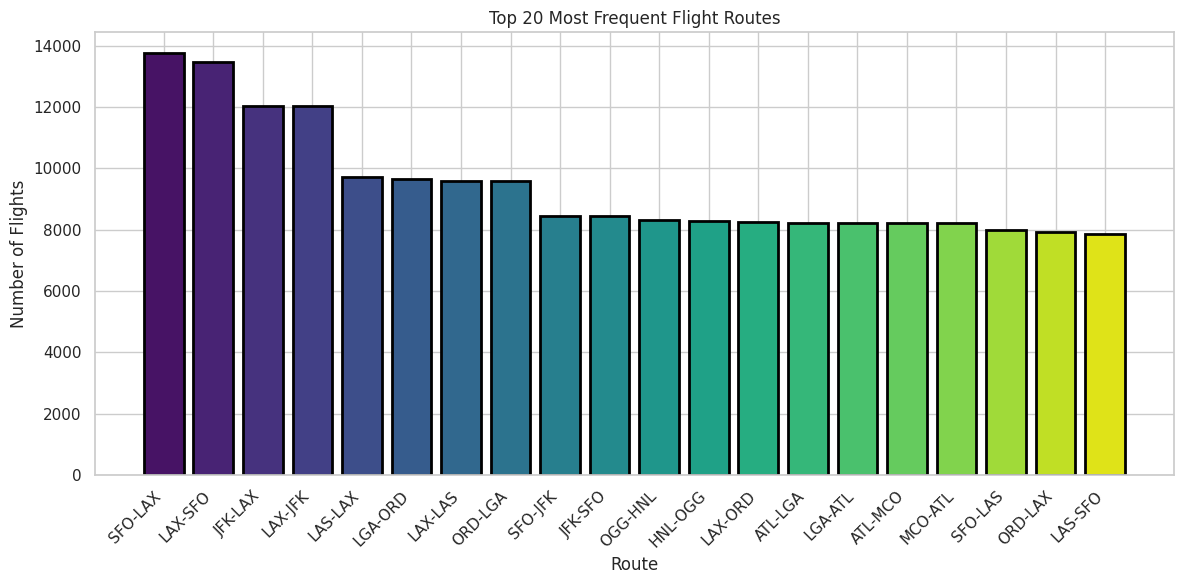

In [8]:
plt.figure(figsize=(12, 6))
# Calculate the top 20 most frequent routes
route_counts = df['ROUTE'].value_counts().head(20)

# Generate a color palette with enough colors for the top 5 routes
colors = sns.color_palette('viridis', len(route_counts))

plt.bar(route_counts.index, route_counts.values, color=colors, edgecolor='black', linewidth=2)
plt.title('Top 20 Most Frequent Flight Routes')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top Routes**

This chart highlights the 20 busiest flight routes:
*   **High Traffic:** SFO-LAX, LAX-SFO, JFK-LAX, and LAX-JFK are the most frequent.
*   **Hub Connections:** Many routes connect major hubs (e.g., ORD, ATL, LGA).
*   **Balanced Demand:** Top routes often appear in both directions.

This shows key travel corridors and dominant airport hubs.

### 5.3: Numbers of Flights by Month.

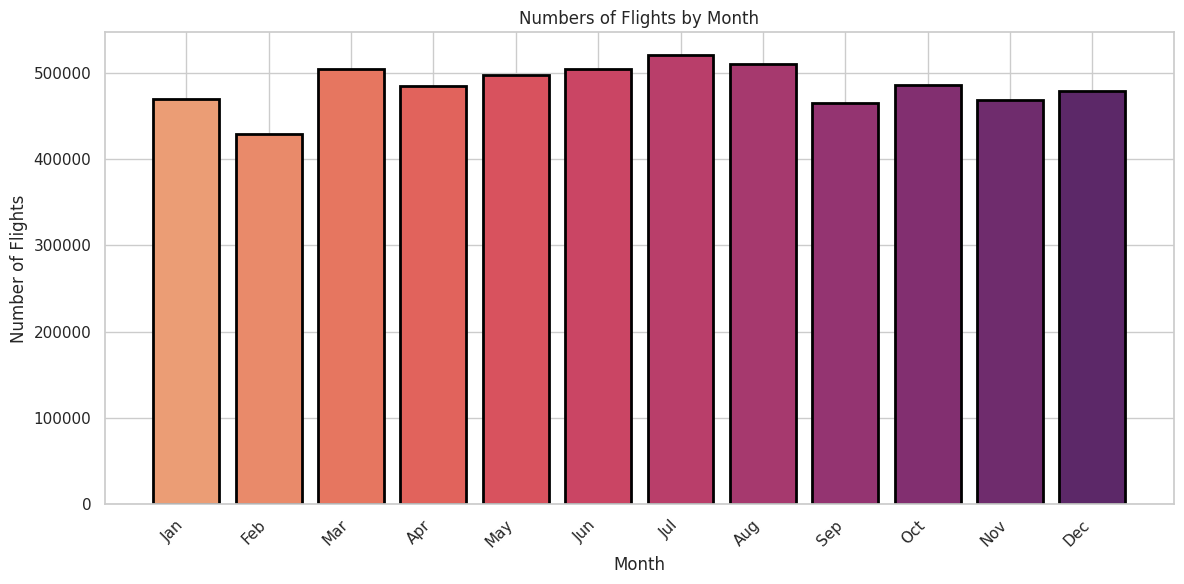

In [10]:
plt.figure(figsize=(12, 6))

# Get current month counts from the DataFrame
current_month_counts = df['MONTH'].value_counts()

# Reindex the series to include all 12 months, filling missing months with 0
month_counts = current_month_counts.reindex(range(1, 13), fill_value=0).sort_index()

color = sns.color_palette("flare", len(month_counts))

plt.bar(month_counts.index, month_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Numbers of Flights by Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

# Create a list of abbreviated month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Set x-axis ticks to be the month numbers and labels to be the month names
plt.xticks(month_counts.index, month_names, rotation=45, ha='right') # Rotate for better readability

plt.tight_layout()
plt.show()

**Interpretation: Flights by Month**

This chart reveals monthly flight patterns:
*   **Peak Months:** July and August show the highest flight volumes (summer travel).
*   **Shoulder Months:** March, May, and June also have high activity.
*   **Low Month:** February has the fewest flights.

Overall, flight activity peaks in summer, with a dip in winter.

### 5.4: Numbers of Flights by Day of the Week.

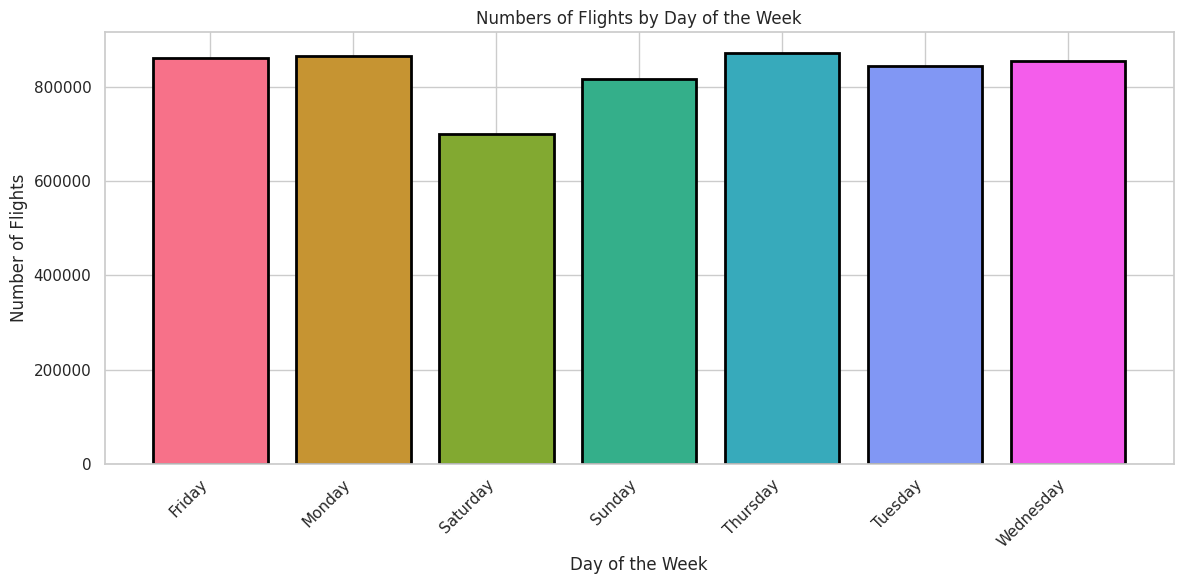

In [13]:
# Bar chat for the number of flights per day
plt.figure(figsize=(12, 6))

week_counts = df['DAY_OF_WEEK_NAME'].value_counts().sort_index()

color = sns.color_palette("husl", len(week_counts))

plt.bar(week_counts.index, week_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Numbers of Flights by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Flights')

plt.xticks(week_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

 **Interpretation: Flights by Day of Week**

This chart reveals weekly flight patterns:
*   **Busiest Days:** Thursday, Monday, and Friday show the highest flight volumes, indicating peak business and start-of-weekend travel.
*   **Mid-Week Activity:** Tuesday and Wednesday maintain strong, consistent flight activity.
*   **Weekend Trends:** Sunday has significant return travel, while Saturday is typically the quietest day for departures.

Overall, air travel is concentrated on weekdays, with a noticeable dip on Saturdays.

### 5.5: Flights on Weekends vs Weekdays (Donut Chart).

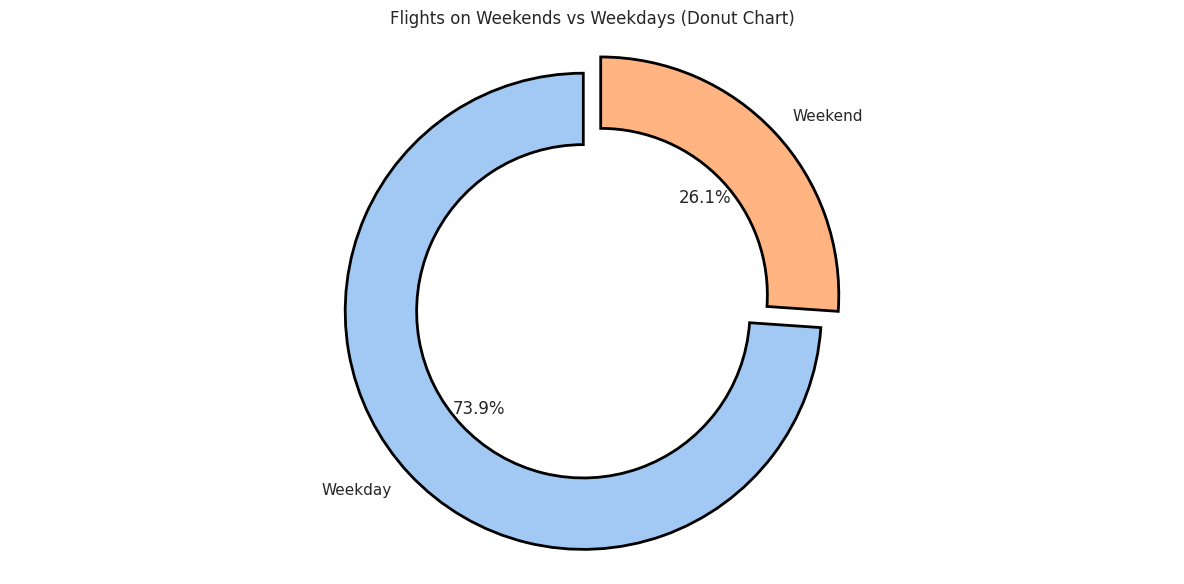

In [50]:
# Donut chart for comparison between flights on weekdays and weekends
plt.figure(figsize=(12, 6))

weekend_counts = df['IS_WEEKEND'].value_counts()
color = sns.color_palette("pastel", len(weekend_counts))

# Create more descriptive labels
descriptive_labels = ['Weekday' if label == False else 'Weekend' for label in weekend_counts.index]


plt.pie(
    weekend_counts.values,
    labels=descriptive_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=color,
    wedgeprops={'width': 0.3, 'edgecolor': 'black', 'linewidth': 2},
    explode=(0.1, 0) # Apply the explode effect to create a gap
)
plt.title('Flights on Weekends vs Weekdays (Donut Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

**Interpretation: Flights on Weekends vs. Weekdays**

This donut chart shows the proportion of flights by day type:
*   **Weekdays Dominant:** A large majority of flights (approximately 74%) occur on weekdays.
*   **Weekend Travel:** Around 26% of flights happen on weekends.

This indicates significantly higher air travel activity during the working week compared to the weekend.

### 5.6: Flights by Departure Time Block.

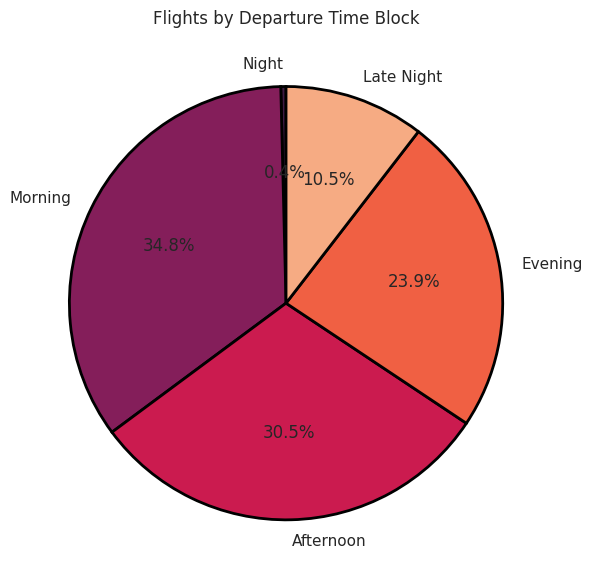

In [33]:
# Pie chart for DEPARTURE_TIME_BLOCK
from datetime import time


plt.figure(figsize=(12, 6))

time_blocks = df['DEPARTURE_TIME_BLOCK'].value_counts().sort_index()

color = sns.color_palette("rocket", len(time_blocks))

plt.pie(
    time_blocks.values,
    labels=time_blocks.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=color,
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}
)
plt.title('Flights by Departure Time Block')
plt.tight_layout()
plt.show()


**Interpretation: Flights by Departure Time Block**

This donut chart illustrates flight distribution across different time blocks:
*   **Peak Hours:** Morning and Afternoon blocks account for the vast majority of flights, indicating high demand during these times.
*   **Evening and Late Night:** These periods have fewer flights but still represent significant activity.
*   **Night:** The 'Night' block has the fewest departures.

Overall, flight operations are heavily concentrated during standard working and daylight hours.

### 5.7: Line plots for DEPARTURE_HOUR and ARRIVAL_HOUR.

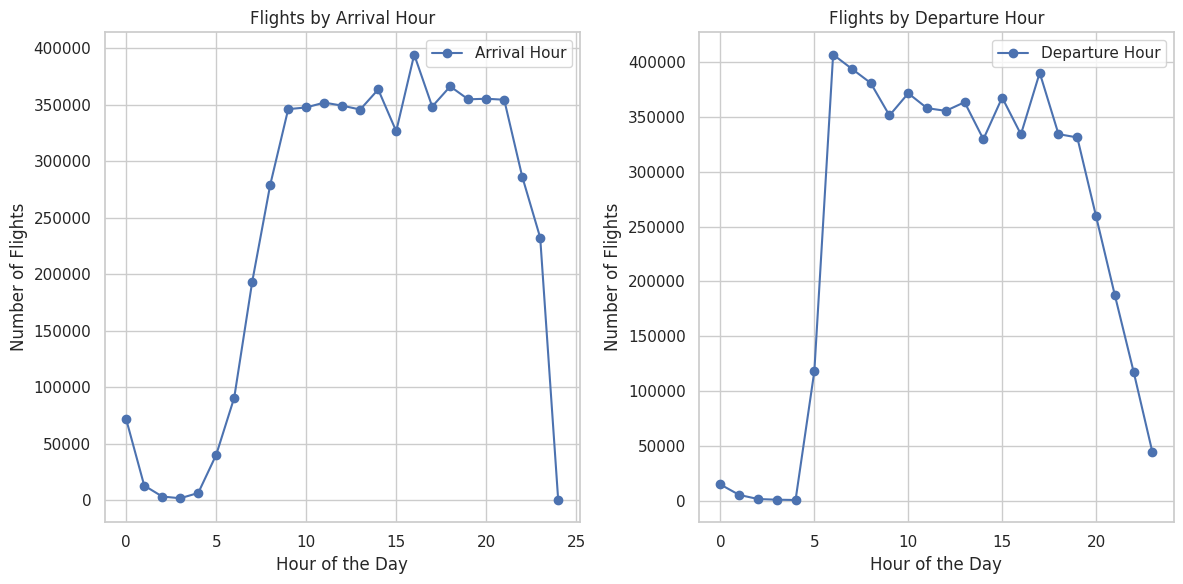

In [55]:
# Line plots for DEPARTURE_HOUR and ARRIVAL_HOUR

plt.figure(figsize=(12, 6))

arrival_hour_counts = df['ARRIVAL_HOUR'].value_counts().sort_index()
departure_hour_counts = df['DEPARTURE_HOUR'].value_counts().sort_index()

# First subplot for Arrival Hour
plt.subplot(1, 2, 1)
plt.plot(arrival_hour_counts.index, arrival_hour_counts.values, label='Arrival Hour', marker='o')
plt.title('Flights by Arrival Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

# Second subplot for Departure Hour
plt.subplot(1, 2, 2)
plt.plot(departure_hour_counts.index, departure_hour_counts.values, label='Departure Hour', marker='o')
plt.title('Flights by Departure Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

plt.tight_layout()
plt.show()

**Interpretation: Flights by Arrival and Departure Hour**

These line plots show the distribution of flights throughout the 24-hour day for both departures and arrivals:

*   **Peak Activity:** Both departures and arrivals show clear peaks during standard working hours, generally from late morning through the evening (e.g., 8 AM - 8 PM), indicating the busiest travel periods.
*   **Early Morning/Late Night:** Flight activity is significantly lower in the very early morning hours (e.g., 1 AM - 5 AM) for both departures and arrivals.
*   **Departure/Arrival Synchronization:** The patterns for departure and arrival hours largely mirror each other, as expected, with flights departing during peak times also arriving during corresponding peak times (allowing for flight duration).

Overall, the plots highlight that air travel is concentrated during the day, with fewer operations during overnight hours.

### 5.8: Top 10 Most Visited Cities.

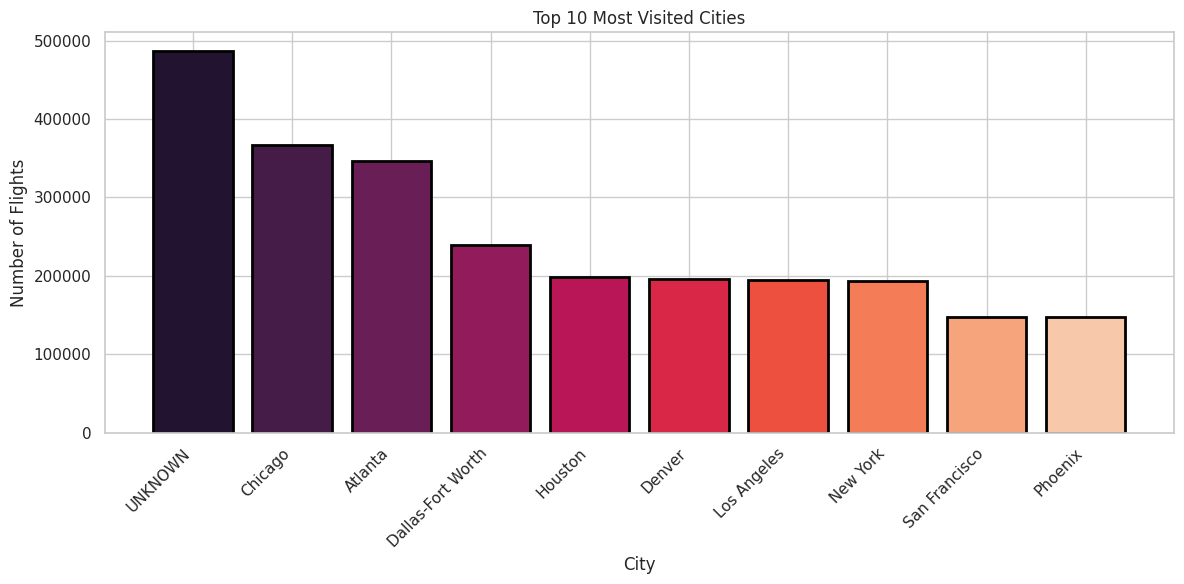

In [56]:
# Bar chart for most visited cities
plt.figure(figsize=(12, 6))

city_counts = df['DESTINATION_CITY'].value_counts().head(10)
color = sns.color_palette("rocket", len(city_counts))

plt.bar(city_counts.index, city_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Top 10 Most Visited Cities')
plt.xlabel('City')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **Interpretation: Top 10 Most Visited Cities**

This chart shows the top 10 cities by flight arrivals:
*   **Leading Destinations:** 'UNKNOWN' has the highest count, followed by major hubs like Chicago, Atlanta, and Dallas-Fort Worth.
*   **Key Travel Hubs:** Cities like Houston, Denver, Los Angeles, and New York are also prominent destinations.

This highlights the busiest urban centers and airports in terms of incoming flight traffic.

### 5.9: Plot for flights distributation in airports.

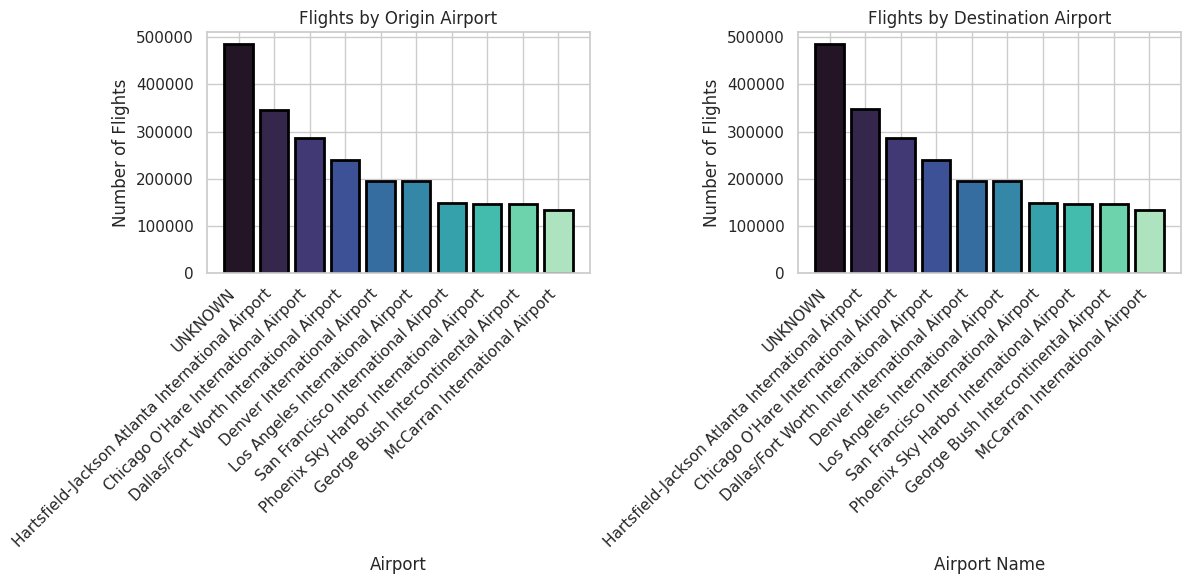

In [59]:
# Plot for flights distributation in airports
plt.figure(figsize=(12, 6))

airport_origin_counts = df['ORIGIN_AIRPORT_NAME'].value_counts().head(10)
airport_destination_counts = df['DESTINATION_AIRPORT_NAME'].value_counts().head(10)

color = sns.color_palette("mako", len(airport_origin_counts))

plt.subplot(1, 2, 1)
plt.bar(airport_origin_counts.index, airport_origin_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Flights by Origin Airport')
plt.xlabel('Airport')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(airport_destination_counts.index, airport_destination_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Flights by Destination Airport')
plt.xlabel('Airport Name')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

 **Interpretation: Flights by Origin and Destination Airport**

These charts display the top 10 airports for both departures and arrivals:
*   **Leading Airports:** 'UNKNOWN' ranks highest for both, followed by major hubs like Hartsfield-Jackson Atlanta, Chicago O'Hare, and Dallas/Fort Worth International Airports.
*   **Key Hubs:** Denver, Los Angeles, and San Francisco International Airports are also consistently prominent.

These plots highlight the busiest air traffic hubs in terms of both departing and arriving flights.

### 5.10: Comparison of Delayed, and On-Time/Early Flights by Departure Hour.

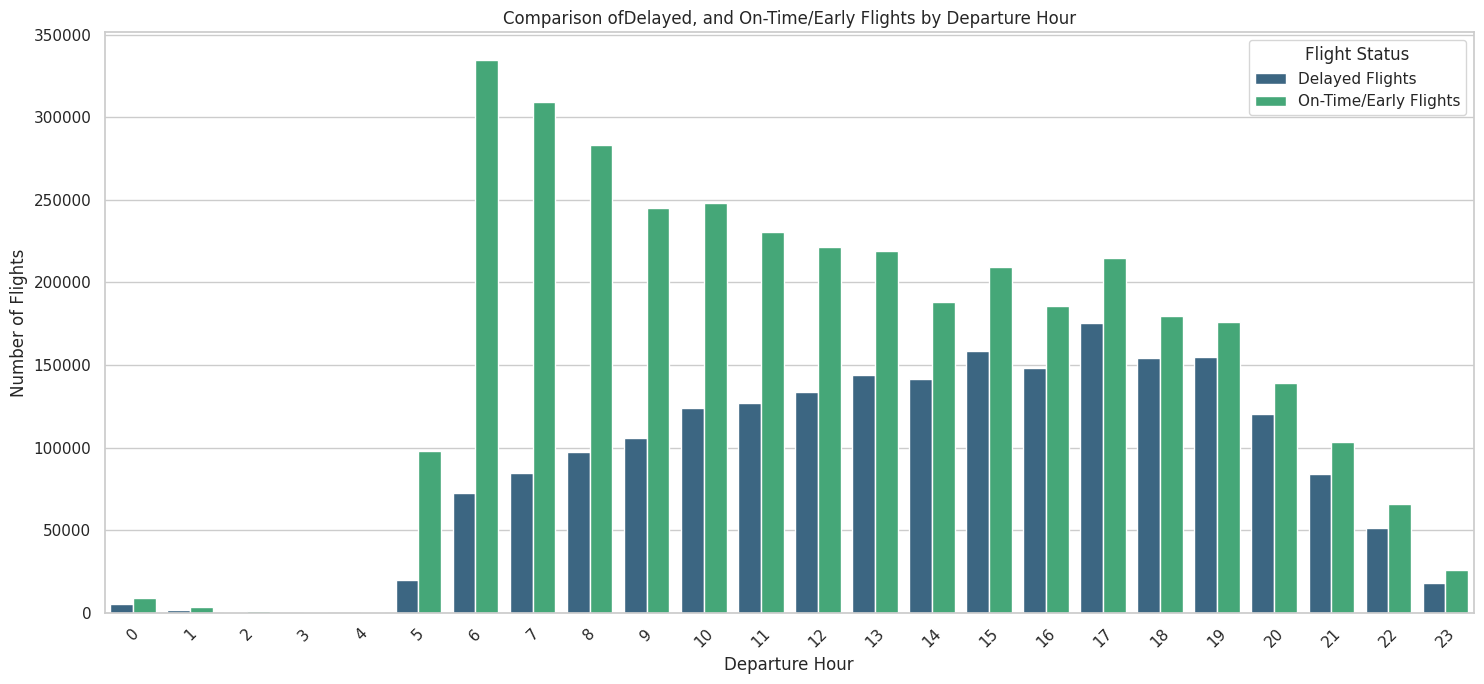

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all hours from 0 to 23 are present for consistent plotting
all_hours = pd.Series(range(24))

# Delayed flights (DEPARTURE_DELAY > 0) per hour
delayed_flights_by_hour = df[df['DEPARTURE_DELAY'] > 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

# On-time or early flights (DEPARTURE_DELAY <= 0) per hour
on_time_early_flights_by_hour = df[df['DEPARTURE_DELAY'] <= 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

# Combine into a single DataFrame for easier plotting with Seaborn
plot_df = pd.DataFrame({
    'Delayed Flights': delayed_flights_by_hour,
    'On-Time/Early Flights': on_time_early_flights_by_hour
}).reset_index()
plot_df = plot_df.rename(columns={'index': 'Departure Hour'})

# Melt the DataFrame to a long format for Seaborn barplot, which is ideal for grouped bar charts
plot_df_melted = plot_df.melt(id_vars='Departure Hour', var_name='Flight Status', value_name='Number of Flights')

plt.figure(figsize=(15, 7))
sns.barplot(data=plot_df_melted, x='Departure Hour', y='Number of Flights', hue='Flight Status', palette='viridis')
plt.title('Comparison of Delayed, and On-Time/Early Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.legend(title='Flight Status')
plt.tight_layout()
plt.show()

 **Interpretation: Hourly Flight Status Comparison**

This grouped bar chart compares total, delayed, and on-time/early flights by departure hour:
*   **Peak Delays:** Delays (red bars) are more prominent during afternoon and evening hours, particularly from late morning onwards, often coinciding with peak total flight activity.
*   **On-Time Performance:** Early morning hours (e.g., 0-6 AM) show a higher proportion of on-time/early flights relative to delayed flights.
*   **Evening Congestion:** As the day progresses, especially in the evening, while total flights remain high, the number and proportion of delayed flights also increase.

This highlights that later departure times are generally more susceptible to delays, likely due to cumulative effects throughout the day.

### 5.11: Flight Distance Distribution by Airline.

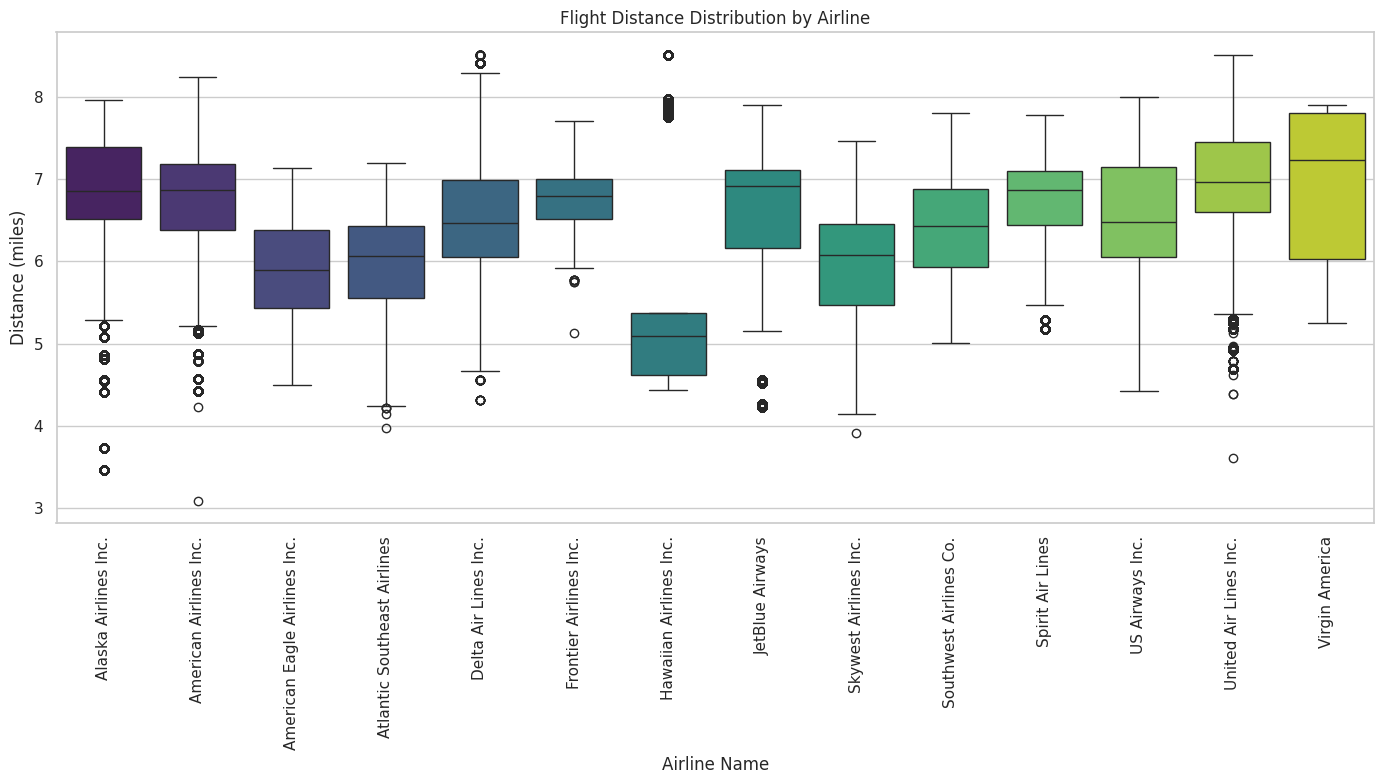

In [67]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='AIRLINE_NAME', y='DISTANCE', data=df, palette='viridis', hue='AIRLINE_NAME', legend=False)
plt.title('Flight Distance Distribution by Airline')
plt.xlabel('Airline Name')
plt.ylabel('Distance (miles)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

 **Interpretation: Flight Distance Distribution by Airline**

This box plot visualizes flight distances per airline:
*   **Varying Medians:** Some airlines (e.g., Southwest, Skywest) have lower median distances, indicating more short-haul flights.
*   **Long-Haul:** Major carriers (e.g., American, Delta, United) show higher median distances, consistent with their national/international routes.
*   **Outliers:** Many airlines have high-distance outliers, suggesting occasional very long flights.
*   **Specialization:** Some airlines show tighter distributions, indicating specialized route lengths.

#**Week 4:** Delay Analysis – Airline and Weather

* Compare delay causes by airline
* Explore carrier delays, weather delays, NAS delays
* Visualize delays by time of day and airport